<a href="https://colab.research.google.com/github/cadmiofreitas/Aula_IA_UNIRP/blob/main/Exemplo_algoritmo_genetico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random


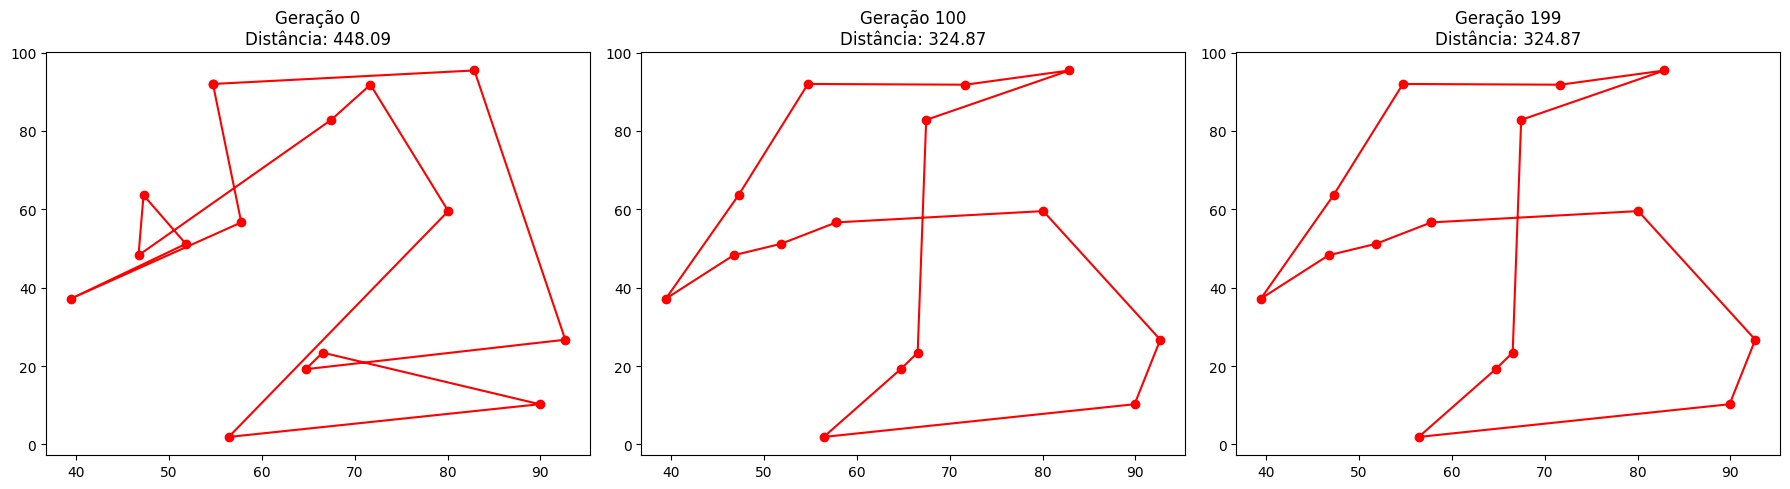

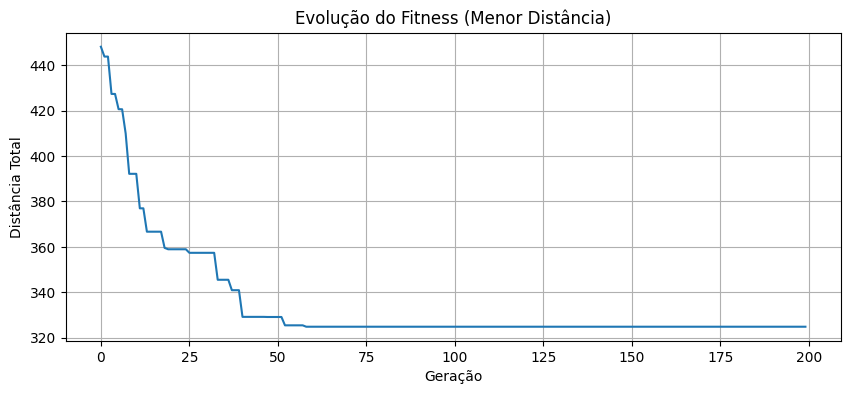

In [ ]:

# 1. Configurações Iniciais
N_CIDADES = 15
POPULACAO_TAM = 100
GERACOES = 200
TAXA_MUTACAO = 0.1

# Criar cidades aleatórias (X, Y)
cidades = np.random.rand(N_CIDADES, 2) * 100

def calcular_distancia(rota):
    # Calcula a distância total de uma rota (indivíduo)
    dist = 0
    for i in range(len(rota)):
        c1 = cidades[rota[i]]
        c2 = cidades[rota[(i + 1) % len(rota)]] # Retorna à origem
        dist += np.linalg.norm(c1 - c2)
    return dist

# 2. Funções do Algoritmo Genético
def criar_populacao():
    return [random.sample(range(N_CIDADES), N_CIDADES) for _ in range(POPULACAO_TAM)]

def crossover(pai1, pai2):
    # Ordered Crossover (OX) para evitar cidades repetidas
    ponto = random.randint(0, N_CIDADES - 2)
    filho = pai1[:ponto]
    for gene in pai2:
        if gene not in filho:
            filho.append(gene)
    return filho

def mutar(rota):
    if random.random() < TAXA_MUTACAO:
        i, j = random.sample(range(N_CIDADES), 2)
        rota[i], rota[j] = rota[j], rota[i]
    return rota

# 3. Execução e Visualização
populacao = criar_populacao()
historico_distancia = []
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fases = [0, GERACOES // 2, GERACOES - 1]

for g in range(GERACOES):
    # Avaliação (Fitness)
    populacao = sorted(populacao, key=lambda x: calcular_distancia(x))
    melhor_dist = calcular_distancia(populacao[0])
    historico_distancia.append(melhor_dist)

    # Print Visual em estágios específicos
    if g in fases:
        idx = fases.index(g)
        ax = axes[idx]
        rota = populacao[0]
        coords = cidades[rota + [rota[0]]]
        ax.plot(coords[:, 0], coords[:, 1], 'ro-')
        ax.set_title(f"Geração {g}\nDistância: {melhor_dist:.2f}")

    # Evolução
    nova_pop = populacao[:10] # Elitismo: mantém os 10 melhores
    while len(nova_pop) < POPULACAO_TAM:
        p1, p2 = random.sample(populacao[:50], 2)
        filho = crossover(p1, p2)
        nova_pop.append(mutar(filho))
    populacao = nova_pop

plt.tight_layout()
plt.show()

# Gráfico de Evolução do Fitness
plt.figure(figsize=(10, 4))
plt.plot(historico_distancia)
plt.title("Evolução do Fitness (Menor Distância)")
plt.xlabel("Geração")
plt.ylabel("Distância Total")
plt.grid(True)
plt.show()